# Download data

In [1]:
from pathlib import Path
from matplotlib import pyplot
from IPython.core.debugger import set_trace

import requests
import numpy as np
import pickle
import gzip
import torch

In [2]:
DATA_PATH = Path("../../data")
PATH = DATA_PATH / "mnist"

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
        content = requests.get(URL + FILENAME).content
        (PATH / FILENAME).open("wb").write(content)

In [3]:
with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

/var/folders/3n/lkls0g113777s2662csfkxc8fpf_g4/T/ipykernel_32760/60285702.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")


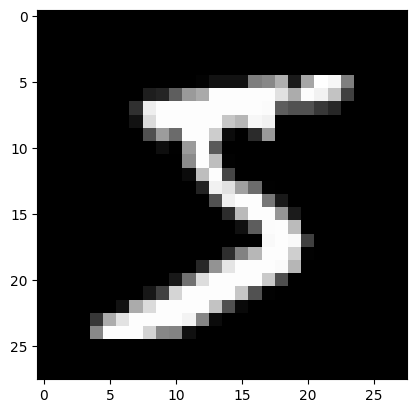

(50000, 784)


In [4]:
pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
pyplot.show()
print(x_train.shape)

In [5]:
x_train, y_train, x_valid, y_valid = map(torch.tensor, (x_train, y_train, x_valid, y_valid))
n, c = x_train.shape
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


# The network

In [6]:
import math

weights = torch.randn(784, 10) / math.sqrt(784)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)

In [7]:
def log_softmax(x):
    return x - x.exp().sum(-1).log().unsqueeze(-1)

def model(xb):
    return log_softmax(xb @ weights + bias)

In [8]:
bs = 64

xb = x_train[0:bs]
preds = model(xb)
preds[0], preds.shape
print(preds[0], preds.shape)

tensor([-1.9673, -2.2280, -2.1219, -2.3873, -2.3313, -1.9930, -2.6862, -2.1924,
        -2.8011, -2.7068], grad_fn=<SelectBackward0>) torch.Size([64, 10])


In [9]:
def nll(input, target):
    return -input[range(target.shape[0]), target].mean()

loss_func = nll

In [10]:
yb = y_train[0:bs]
print(loss_func(preds, yb))

tensor(2.3912, grad_fn=<NegBackward0>)


In [11]:
def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()

In [12]:
print(accuracy(preds, yb))

tensor(0.0625)


In [20]:
lr = 0.5
epochs = 2

for epoch in range(epochs):
    for i in range((n - 1) // bs + 1):
        start_i = i*bs
        end_i = start_i + bs
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        with torch.no_grad():
            weights -= weights.grad * lr
            bias -= bias.grad * lr
            weights.grad.zero_()
            bias.grad.zero_()

In [21]:
print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(0.0648, grad_fn=<NegBackward0>) tensor(1.)


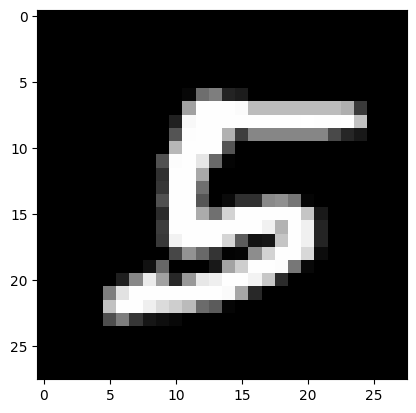

The model believes this is the number: 5
tensor(5)


In [39]:
selected_val = x_valid[111]
pyplot.imshow(selected_val.reshape((28, 28)), cmap="gray")
pyplot.show()

# The guess:
prediction = model(selected_val)
print(f"The model believes this is the number: { prediction.argmax() }")
print(y_valid[111])